In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import seaborn as sns
from pandas.api.types import CategoricalDtype
import scipy as sp
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color

In [2]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)
path

WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/WT_500pM-HUGS_100nM-HUS_100ms_500mspf/2021-06-01_CH2_400pM-WT-HUGS_200nM-WT-HUS/CH2_1.5gauss/1gauss/TH6.5')

In [3]:
spots = pd.read_csv(path/'Spots in tracks statistics.csv', encoding='utf-8')
data = pd.read_csv(path/'Track statistics.csv', encoding='utf-8')

In [4]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
yellow = '#FFCB05'

In [5]:
data

,Label,TRACK_ID,NUMBER_SPOTS,NUMBER_GAPS,LONGEST_GAP,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,TRACK_DURATION,TRACK_START,...,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TRACK_MAX_QUALITY,TRACK_MIN_QUALITY,TRACK_MEDIAN_QUALITY,TRACK_STD_QUALITY
0,Track_0,0,3,0,0,0,0,0,2,2,...,1.465,2.069,0.861,2.069,0.854,7.476,8.932,6.630,6.866,1.034
1,Track_1,1,3,0,0,0,0,0,2,2,...,0.623,0.640,0.607,0.640,0.023,8.804,11.498,7.353,7.559,1.907
2,Track_2,2,9,1,1,0,0,0,9,1,...,0.295,0.416,0.158,0.338,0.094,7.946,9.619,6.834,7.774,0.898
3,Track_3,3,5,0,0,0,0,0,4,0,...,0.821,1.494,0.395,0.836,0.485,8.697,10.743,7.283,8.579,1.291
4,Track_4,4,35,0,0,0,0,0,34,0,...,0.388,1.687,0.046,0.317,0.300,11.266,15.693,8.572,11.352,1.479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6762,Track_6762,6762,2,0,0,0,0,0,1,397,...,0.608,0.608,0.608,0.608,NaN,7.655,8.790,6.520,8.790,1.135
6763,Track_6763,6763,2,0,0,0,0,0,1,397,...,0.048,0.048,0.048,0.048,NaN,8.588,9.150,8.025,9.150,0.562
6764,Track_6764,6764,2,0,0,0,0,0,1,397,...,0.525,0.525,0.525,0.525,NaN,8.069,8.576,7.562,8.576,0.507
6765,Track_6765,6765,2,0,0,0,0,0,1,397,...,0.495,0.495,0.495,0.495,NaN,7.929,8.775,7.083,8.775,0.846


In [6]:
def open_roi_line(name):
    roi_path = path/(name)

    roi_data = read_roi_zip(roi_path)
    roi_df = pd.DataFrame(columns=['Track ID','x1','x2','y1','y2'])
    for key in roi_data:
        roi_df = roi_df.append({'Track ID': roi_data[key]['name'],'x1': roi_data[key]['x1'],'x2': roi_data[key]['x2'],'y1': roi_data[key]['y1'],'y2': roi_data[key]['y2']}, ignore_index=True)
    return roi_df

In [7]:
lines = open_roi_line('kymolines.zip')

In [8]:
def mask_dots(lines):
    maskdotsx = []
    maskdotsy = []
    for i in list(lines.index):
        maskdotsx = maskdotsx + list(np.linspace(lines['x1'][i],lines['x2'][i],30))
        maskdotsy = maskdotsy + list(np.linspace(lines['y1'][i],lines['y2'][i],30))
    return maskdotsx,maskdotsy

In [9]:
maskdots = mask_dots(lines)
len(maskdots[0])

1890

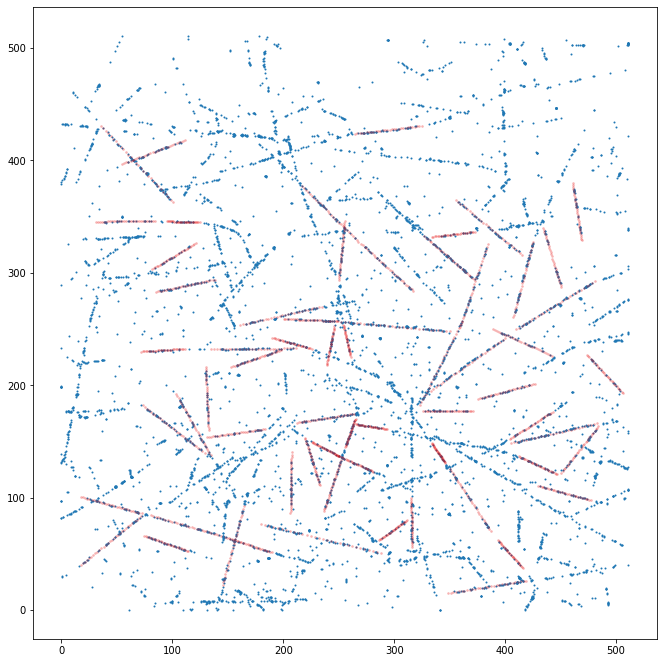

In [10]:
x=data['TRACK_X_LOCATION']
y=data['TRACK_Y_LOCATION']
scattersize = 1
cap = 5
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)
ax.scatter(maskdots[0] , maskdots[1], color=red,s = scattersize*3, alpha=0.2);

In [13]:
i= 0
R = 2.5
xy = data[['TRACK_X_LOCATION','TRACK_Y_LOCATION']]
square = xy[(xy['TRACK_X_LOCATION']<(maskdots[0][i]+R)) & (xy['TRACK_X_LOCATION']>(maskdots[0][i]-R)) 
                    & (xy['TRACK_Y_LOCATION']<(maskdots[1][i]+R)) & (xy['TRACK_Y_LOCATION']>(maskdots[1][i]-R))]
square

,TRACK_X_LOCATION,TRACK_Y_LOCATION
4901,321.366,184.014


In [14]:
def filter_maskroi(data,maskdots,R):
    
    xy = data[['TRACK_X_LOCATION','TRACK_Y_LOCATION']]
    squareindex = []
    
    for i in np.arange(0,len(maskdots[0])): #

        square = xy[(xy['TRACK_X_LOCATION']<(maskdots[0][i]+R)) & (xy['TRACK_X_LOCATION']>(maskdots[0][i]-R)) 
                    & (xy['TRACK_Y_LOCATION']<(maskdots[1][i]+R)) & (xy['TRACK_Y_LOCATION']>(maskdots[1][i]-R))]
        
        squareindex0 = list(square.index)
        
        squareindex = squareindex + squareindex0
        
    squareindex = list(set(squareindex))
    
    data0 = data[data.index.isin(squareindex)]
        
    return data0

2151


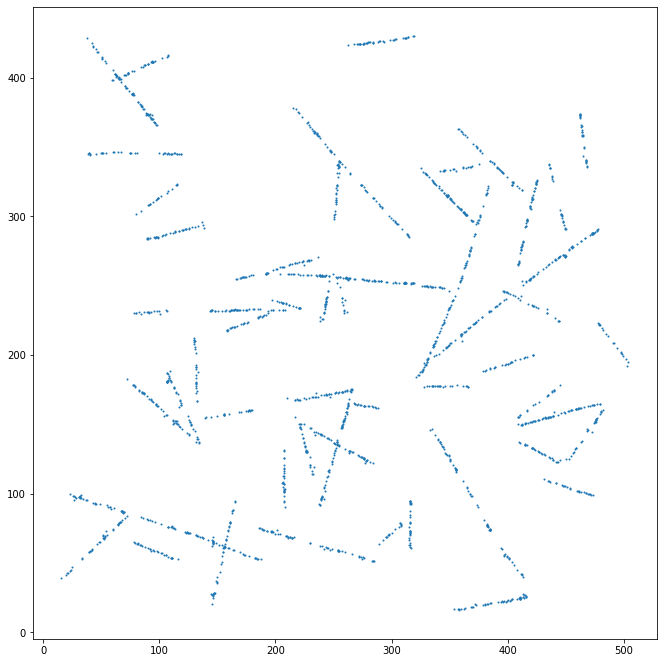

In [15]:
data0 = filter_maskroi(data,maskdots,R)
print(len(data0))
x=data0['TRACK_X_LOCATION']
y=data0['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)

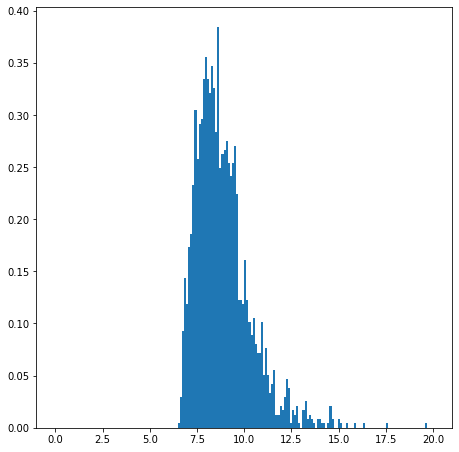

In [16]:
y=data0['TRACK_MEAN_QUALITY']
scattersize = 1
cap = 5
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 20 + 0.11, 0.11), density=True);

In [17]:
min_duration = 10
startstop = 5
lastframe = data['TRACK_STOP'].max()
data1 = data0[(data0['TRACK_START']>=startstop) & (data0['TRACK_STOP']<=(lastframe-startstop)) & (data0['TRACK_DURATION']>=min_duration)]
data1

,Label,TRACK_ID,NUMBER_SPOTS,NUMBER_GAPS,LONGEST_GAP,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,TRACK_DURATION,TRACK_START,...,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TRACK_MAX_QUALITY,TRACK_MIN_QUALITY,TRACK_MEDIAN_QUALITY,TRACK_STD_QUALITY
334,Track_334,334,31,1,1,0,0,0,31,5,...,0.572,1.529,0.102,0.503,0.345,10.547,15.406,7.153,9.951,2.113
358,Track_358,358,21,3,1,0,0,0,23,5,...,0.380,0.888,0.069,0.331,0.259,10.190,14.560,6.870,10.056,2.259
359,Track_359,359,14,0,0,0,0,0,13,5,...,0.562,2.006,0.062,0.516,0.491,11.062,17.115,6.851,11.172,2.953
374,Track_374,374,16,2,4,0,0,0,20,6,...,0.457,0.910,0.035,0.459,0.283,10.786,16.393,6.668,9.753,3.077
376,Track_376,376,8,1,3,0,0,0,10,6,...,0.530,0.910,0.124,0.608,0.344,7.880,9.157,6.811,7.912,0.899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6384,Track_6384,6384,12,0,0,0,0,0,11,370,...,0.273,0.752,0.075,0.202,0.206,10.897,13.119,8.348,10.701,1.708
6400,Track_6400,6400,11,0,0,0,0,0,10,371,...,0.628,1.007,0.194,0.777,0.288,10.657,15.793,6.624,8.785,3.172
6475,Track_6475,6475,8,3,4,0,0,0,14,376,...,0.368,0.906,0.102,0.197,0.326,7.522,8.653,6.859,7.512,0.550
6504,Track_6504,6504,9,1,3,0,0,0,11,378,...,0.523,1.337,0.057,0.474,0.472,7.445,9.692,6.598,6.945,0.972


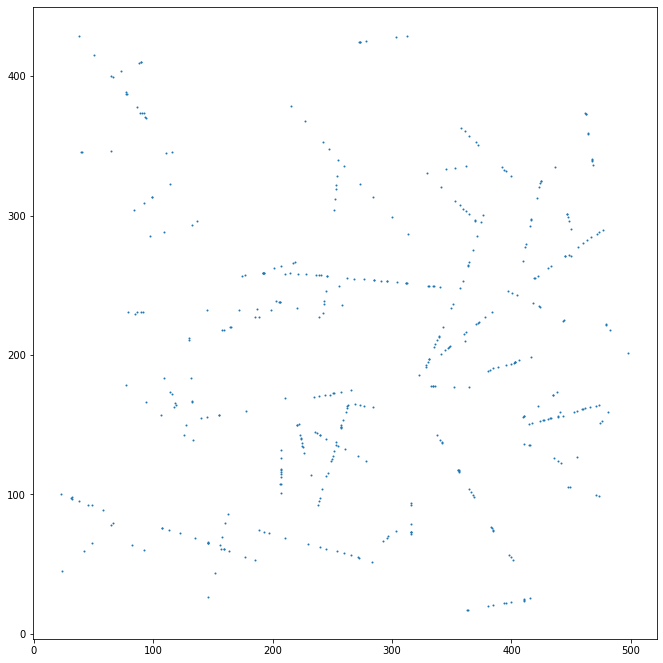

In [18]:
x=data1['TRACK_X_LOCATION']
y=data1['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)

In [19]:
def filter_neighbors(data0,R,N,iterations):
    
    for k in range(iterations):
        xy = data0[['TRACK_X_LOCATION','TRACK_Y_LOCATION']]
        for i in list(xy.index): #

            xyvalue = xy.loc[i].values
            xvalue = xyvalue[0]
            yvalue = xyvalue[1]

            square = xy[(xy['TRACK_X_LOCATION']<(xvalue+R)) & (xy['TRACK_X_LOCATION']>(xvalue-R)) & (xy['TRACK_Y_LOCATION']<(yvalue+R)) & (xy['TRACK_Y_LOCATION']>(yvalue-R))]

            if (len(square) < N):
                try:
                    data0 = data0.drop(square.index)
                except KeyError:
                     continue

    return data0

In [20]:
# data1 = filter_neighbors(data0,10,2,1)

# x=data1['TRACK_X_LOCATION']
# y=data1['TRACK_Y_LOCATION']
# fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
# ax.scatter(x , y , s = scattersize)

## Spots ##

In [21]:
spots

,Label,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,...,MANUAL_COLOR,MEAN_INTENSITY,MEDIAN_INTENSITY,MIN_INTENSITY,MAX_INTENSITY,TOTAL_INTENSITY,STANDARD_DEVIATION,ESTIMATED_DIAMETER,CONTRAST,SNR
0,ID303331,303331,0,6.866,221.758,357.406,0,2,2,2.5,...,-10921639,201.757,201,190,215,7465,6.504,4.413,0.023,1.423
1,ID303620,303620,0,6.630,221.829,358.265,0,3,3,2.5,...,-10921639,200.216,199,187,213,7408,6.729,4.423,0.023,1.344
2,ID304485,304485,0,8.932,221.998,356.202,0,4,4,2.5,...,-10921639,205.703,204,193,223,7611,8.360,4.414,0.032,1.535
3,ID303336,303336,1,7.353,440.100,364.223,0,2,2,2.5,...,-10921639,184.919,184,174,202,6842,7.266,4.403,0.029,1.418
4,ID303622,303622,1,7.559,439.464,364.289,0,3,3,2.5,...,-10921639,187.135,186,175,204,6924,7.631,4.395,0.027,1.270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50878,ID367437,367437,6764,7.562,186.764,46.107,0,398,398,2.5,...,-10921639,188.838,189,174,205,6987,8.392,4.385,0.025,1.103
50879,ID367214,367214,6765,8.775,390.892,122.503,0,397,397,2.5,...,-10921639,204.270,202,190,225,7558,9.677,4.404,0.029,1.192
50880,ID367463,367463,6765,7.083,390.514,122.823,0,398,398,2.5,...,-10921639,204.378,205,190,221,7562,8.156,4.402,0.023,1.132
50881,ID367229,367229,6766,7.677,315.890,164.923,0,397,397,2.5,...,-10921639,200.865,202,185,211,7432,7.099,4.414,0.029,1.612


In [22]:
trackID = data1['TRACK_ID']
filteredspots = spots[spots['TRACK_ID'].isin(trackID)]

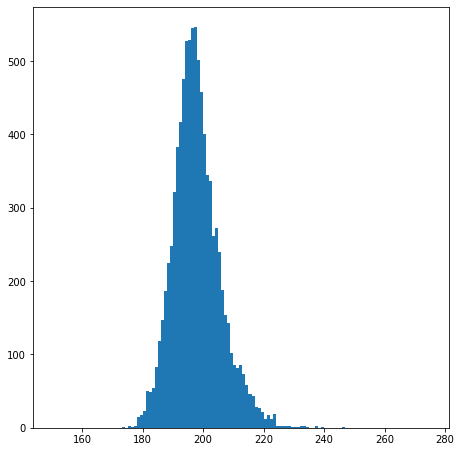

In [23]:
y=filteredspots['MEAN_INTENSITY']
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(150, 275 + 1, 1));

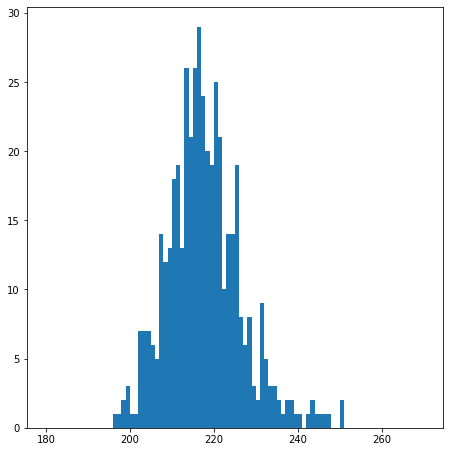

In [24]:
meantrackspots =filteredspots.groupby('TRACK_ID').mean()
y = meantrackspots['MAX_INTENSITY']
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(180, 270 + 1, 1));

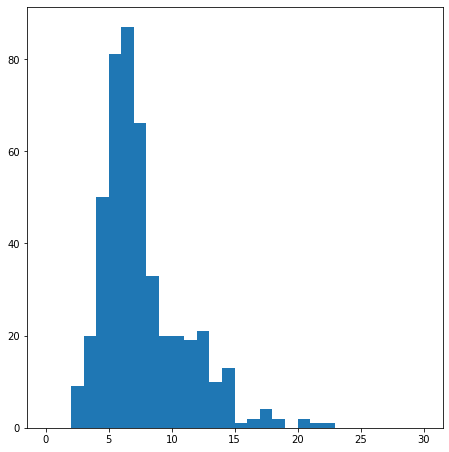

In [25]:
stdtrackspots =filteredspots.groupby('TRACK_ID').std()
y = stdtrackspots['MAX_INTENSITY']
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 30 + 1, 1));

445


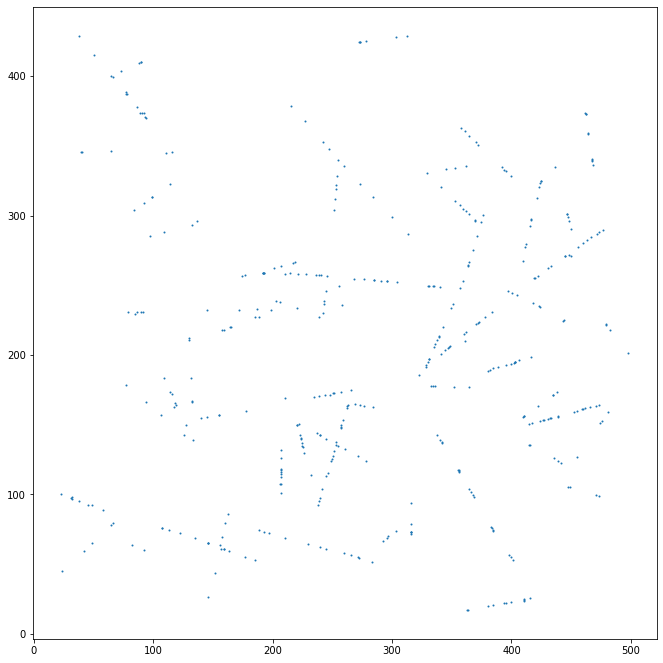

In [29]:
brightspotsID = meantrackspots[(meantrackspots['MAX_INTENSITY'] < 195) | (meantrackspots['MAX_INTENSITY'] > 235)].index.values
data2 = data1[~data1['TRACK_ID'].isin(brightspotsID)]
print(len(data2))

x=data2['TRACK_X_LOCATION']
y=data2['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)

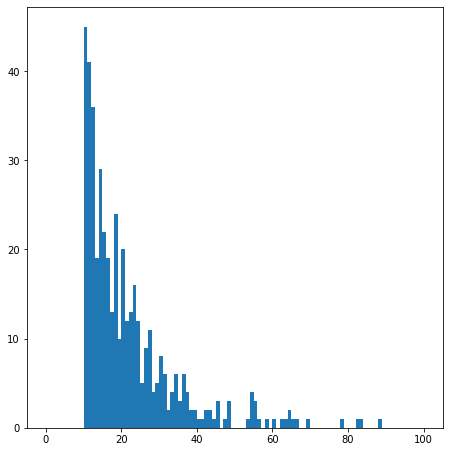

In [30]:
y=data2['TRACK_DURATION']
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 100 + 1, 1));

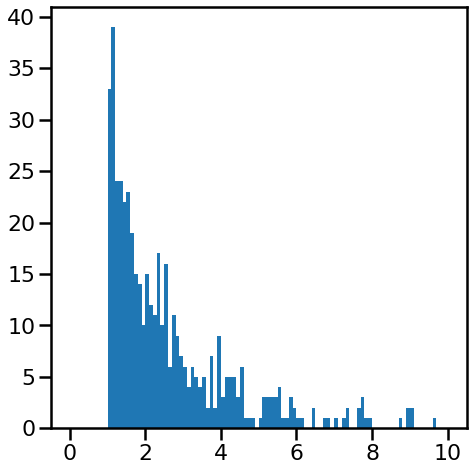

In [258]:
track_duration=data2['TRACK_DURATION']*0.1
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(track_duration, bins=np.arange(0, 10 + 0.1, 0.1));

## Exponential Fit ##

In [259]:
def exponential(x, scale):
    return ((np.exp(-x/scale) )/(scale))

def equation_fit(track_duration,x):
    
    equation = exponential
        
    results = pd.DataFrame(columns=[] , index=[])
    
    n, bins, patches = ax.hist(track_duration, bins=x, density=True);
                
    coeff, var_matrix = sp.optimize.curve_fit(equation,bins[:-1],n)

    variance = np.diagonal(var_matrix) #Refer [3]
    SE = np.sqrt(variance) #Refer [4]

            #======Making a data frame========
    results0 = pd.DataFrame(columns=[] , index=[])
    
    for k in np.arange(0,len(coeff)):
        header = [np.array(['Exponential']),np.array(['Coefficient '+ str(k)])]
        r0 = pd.DataFrame([coeff[k],SE[k]], index=(['Value','SE']),columns= header)
        results0 = pd.concat([results0, r0], axis=1, sort=False)

    results = pd.concat([results, results0], sort=False)

    return results


In [260]:
spf = 0.1
DCXconc=str(200)
DCXType = 'WT'
xlim = 10
bins = 0.1

x = np.arange(min_duration*spf, xlim + bins, bins)

shift = min_duration*spf

track_duration_shift=(track_duration.add(-shift)) #times 100ms
EqFit = equation_fit(track_duration,x)

#EqFit.loc['Value'] = EqFit.loc['Value'].add((min_duration-1)*spf)

scale = EqFit['Exponential']['Coefficient 0'].loc['Value']
#x0 = EqFit['Exponential']['Coefficient 1'].loc['Value']
EqFit

,Exponential
,Coefficient 0
Value,1.516269
SE,0.369131


In [261]:
true_scale = EqFit['Exponential']['Coefficient 0'].loc['Value']+((min_duration)*spf)
SE = EqFit['Exponential']['Coefficient 0'].loc['SE']
scalestr = str(round(true_scale,2))
SEstr = str(round(SE,3))
scalestr,SEstr

('2.52', '0.369')

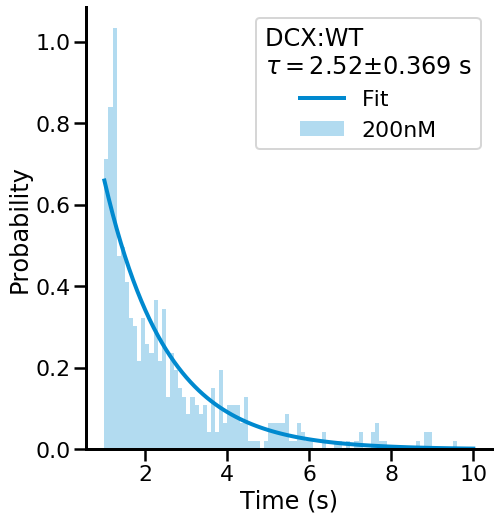

In [262]:
color=cyan

fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(track_duration, bins=x, density=True,color = color,alpha = 0.3);
ax.plot(x,exponential(x-shift,scale),color = color, lw=4);
ax.set_xlabel('Time (s)')
ax.set_ylabel('Probability')
#ax.set_ylim(0,1.2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)

ax.legend(('Fit',DCXconc + 'nM'),loc='upper right',title='DCX:' + DCXType +' \n' r'$\tau = $' + scalestr + r'$\pm $'  + SEstr + ' s')

sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()
plt.savefig(path/('track-duration_expo-fit.pdf'))